# 2 - Angle tag applier.
This notebook implements the model deveoloped in the `/notebooks/machine learning notebooks/2 - Angle classifier.ipynb` notebook. The outcome of that notebook was that both ways of training the data will be used, with a hard voting being done at the end - model that outputs the highest certainty is the winner. 

Since notebook 1 showed us that sometimes an image is usable, sometimes it isn't depending on the chosen model, I'll run both models against the full dataset of images. This has one major advantage: if I improve the bintagger alghorithm, I already have an angle tagger. It could also be interesting to see what the certainty scores are of predicted angles of 'crappy' images versus 'good' images; though the latter is an idea for further research and not the point of this exercise. 

The output of this data will be stored in SQL with four columns being used (two per model: tag and certainty) for storing the predictions and one column to reference the primary key of an image.

In [1]:
import pandas as pd
#from PIL import Image
#import matplotlib.pyplot as plt
import tensorflow as tf

import os
import sys
import numpy as np
import tensorflow as tf
import json
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append('../../utils')
import config_handling as conf
from database import Database
import file_io 
import implot
import cnn_helpers

2025-03-08 08:44:28.204926: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2.1 Settings for this notebook

Setting 

In [2]:
CONFFILE = '../../config/automotive.conf.ini'
BATCH_SIZE = 1000
USE_BBOXES = True
SHAPE = 256

In [3]:
basedir, db  = conf.applyconf(CONFFILE)

Connection established


In [4]:
confdata = conf.read_config(CONFFILE)

In [5]:
table_query = """CREATE TABLE IF NOT EXISTS angletag_predicts (
    image_id INT PRIMARY KEY,
    model_label VARCHAR(32), 
    model_score FLOAT
);"""
db.execute_query(table_query)

[]

In [6]:
cnn_helpers.system_override()
device = cnn_helpers.system_pick_device()

System override applied - check if GPU is detected
Using GPU for deep learning.


2025-03-08 08:44:30.351458: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-03-08 08:44:32.762067: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-03-08 08:44:32.762144: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


In [7]:
dirs = confdata['directories']
angle_model_dir = os.path.join(dirs['root_dir'], dirs['final_models_dirname'], dirs['final_angle_dir'])


angle_model = cnn_helpers.load_one_model(angle_model_dir)

2025-03-08 08:44:32.794676: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-03-08 08:44:32.794811: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-03-08 08:44:32.794862: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-03-08 08:44:32.794962: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-03-08 08:44:32.795015: I external/local_xla/xla/stream_executor/rocm/rocm_executor.

In [8]:
def load_jsondump_to_encoder(dir, extension = '.json', key_to_int = True):
    files = [f for f in os.listdir(dir) if f.endswith(extension)]
    assert len(files) > 0
    file = files[0]
    filedir = os.path.join(dir, file)
    print(filedir)
    file = open(filedir, 'r', encoding='utf8')
    content = json.load(file)
    file.close()
    if key_to_int: 
        content = {int(k): v for k, v in content.items()}
    return content

labeldict = load_jsondump_to_encoder(angle_model_dir)

/home/frederic/Documents/automotive_project/final models/angles/encoded_labels.json


## 2.2 Make the predictions: 
We'll be using a loop to predict

In [9]:
last_record_query = "SELECT MAX(image_id) as id FROM angletag_predicts"
last_record = db.execute_query(last_record_query)
record_id = int(last_record[0]['id']) if last_record[0]['id'] is not None else 0
print(f"Starting from {record_id} in batches of {BATCH_SIZE}")

Starting from 16307535 in batches of 1000


In [10]:
img_query = "SELECT * FROM images WHERE id > %s ORDER BY id ASC LIMIT %s;"
img_table = pd.DataFrame(db.execute_query(img_query, [record_id, BATCH_SIZE]))
while len(img_table) > 0:
    img_table = cnn_helpers.cast_bbox_values(img_table)
    img_table = file_io.make_absolute_path(img_table, basedir, 'image_path', 'abs_path', True)
    images = []
    ids = []
    for _, row in img_table.iterrows():
        record_id = row['id']
        image = row['abs_path']
        bboxvalues = [row['yolobox_top_left_x'],row['yolobox_top_left_y'],row['yolobox_bottom_right_x'],row['yolobox_bottom_right_y']]
        img_matrix = cnn_helpers.preprocess_image(image, USE_BBOXES, bboxvalues, SHAPE)
        images.append(img_matrix)
        ids.append(record_id)
    predictions = angle_model.predict(np.array(images), verbose=0)  #disable progress bar so it can print and override the record_id
    prediction_integers = np.argmax(predictions, axis=1) #get int labels of prediciton
    prediction_labels = [labeldict[i] for i in prediction_integers]  #get the string labels
    scores = np.max(predictions, axis=1)  #get the certainty score  
    img_table = pd.DataFrame(db.execute_query(img_query, [record_id, BATCH_SIZE]))
    db.start_transaction()
    for id, label, score in zip(ids, prediction_labels, scores):
        insert_query = "INSERT INTO angletag_predicts VALUES(%s, %s, %s)"
        insert_data = [id, label, score]
        db.execute_query(insert_query, insert_data)
    db.commit_transaction()

    print(record_id, end='\r', flush=True)    

    


## 2.3 Exploring prediction outcomes:
In phase 1 we decided that a good indication for now is to use images where two models are above the 0.9 treshold. We'll be applying that same treshold here for our plots. Reason all images received an angle tag is that if we manage to improve the usability tagger in phase 1; then we don't need to redo part two for the newly introduced images. 

An interesting plot to make is the confidence score of the angle tagger, versus the usability score. I'm expecting both to be lineair. Images that are not usefull and thus have a low usability score, should have a small confidence score from the angle tagger as that second model wasn't trained on bad images. 

In [11]:
TRESHOLD = 0.9
MINMODELS = 2

In [12]:
base_query = f"""
    SELECT angletag_predicts.*, images.image_path, bintag_predicts.*
    FROM images
    JOIN bintag_predicts ON bintag_predicts.image_id = images.id
    JOIN angletag_predicts ON angletag_predicts.image_id = images.id
    WHERE 
        (CASE WHEN model1_results >= {TRESHOLD} THEN 1 ELSE 0 END + 
        CASE WHEN model2_results >= {TRESHOLD} THEN 1 ELSE 0 END + 
        CASE WHEN model3_results >= {TRESHOLD} THEN 1 ELSE 0 END + 
        CASE WHEN model4_results >= {TRESHOLD} THEN 1 ELSE 0 END)
    >= {MINMODELS};
    """
base_data = db.execute_query(base_query)

In [44]:
df = pd.DataFrame(base_data)
df = file_io.make_absolute_path(df, basedir, 'image_path', 'abs_path')

In [45]:
df.sample(10)

,image_id,model_label,model_score,bintag_predicts.image_id,model1_results,model2_results,model3_results,model4_results,abs_path
1719573,6827271,rearright,1.000000,6827271,0.998150,0.999998,0.996974,0.988103,/home/frederic/Documents/automotive_image_data...
2773905,10563677,frontright,1.000000,10563677,0.997588,1.000000,0.999693,0.997436,/home/frederic/Documents/automotive_image_data...
3525635,14127486,right,1.000000,14127486,0.984719,0.999821,0.969855,0.939954,/home/frederic/Documents/automotive_image_data...
84998,546552,front,1.000000,546552,0.998597,1.000000,0.999456,0.999937,/home/frederic/Documents/automotive_image_data...
1755373,6946656,rearleft,0.999861,6946656,0.990884,0.972882,0.784981,0.963458,/home/frederic/Documents/automotive_image_data...
2167085,8383399,rear,1.000000,8383399,0.999504,0.970257,0.476122,0.529743,/home/frederic/Documents/automotive_image_data...
1207050,4560925,rearright,0.999974,4560925,0.990749,0.999540,0.965514,0.982400,/home/frederic/Documents/automotive_image_data...
1768657,6992197,front,1.000000,6992197,0.943617,1.000000,0.998970,0.996254,/home/frederic/Documents/automotive_image_data...
3493296,13976809,rearleft,0.616838,13976809,0.973216,0.999551,0.984528,0.994234,/home/frederic/Documents/automotive_image_data...
2095313,8125635,rear,1.000000,8125635,0.995573,0.999885,0.967359,0.778034,/home/frederic/Documents/automotive_image_data...


''

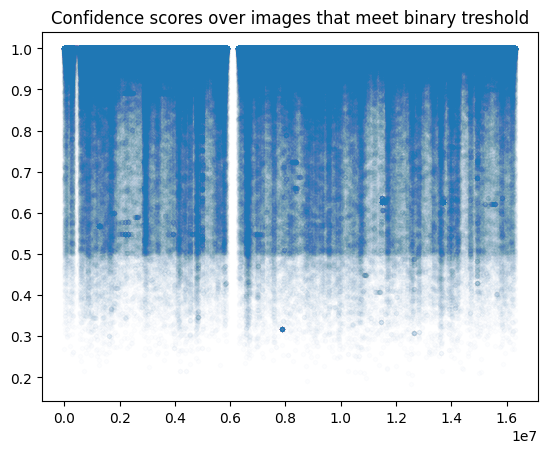

In [15]:
plt.scatter(
    x=df.image_id,
    y=df.model_score,
    marker='.',
    alpha=0.01
    )
plt.title('Confidence scores over images that meet binary treshold')
;

this horizontal line is something we wanted to see - that's because of the binary-tag being applied to it. The vertical line at 6million is a bunch of missing ids. During scraping a large chuck was not committed and got redone. This has no effect. 

In [16]:
count = df.value_counts('model_label').reset_index()

''

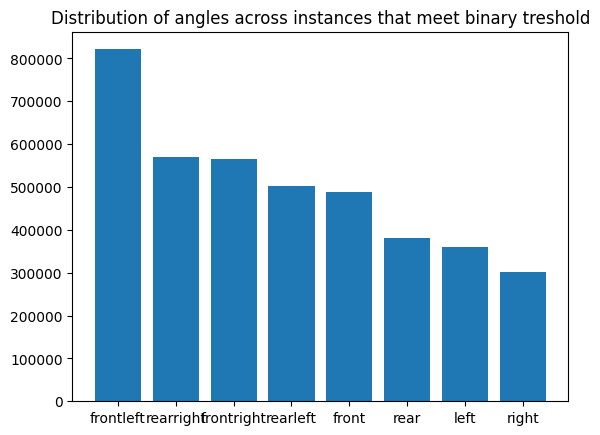

In [17]:
plt.bar(count['model_label'], count['count'])
plt.title('Distribution of angles across instances that meet binary treshold')
;

This plot is close in shape to the plot of the original manually tagged dataset. So that's good too. 

''

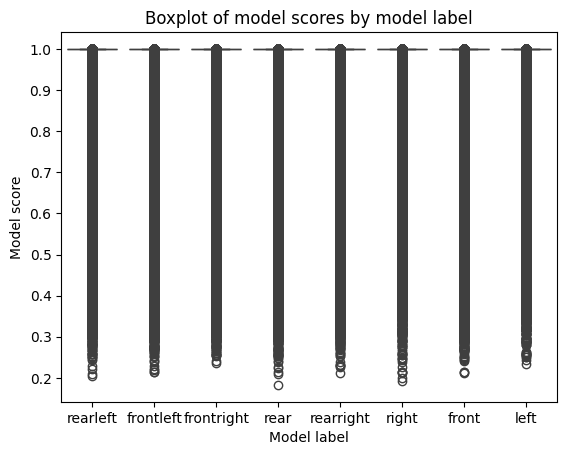

In [18]:
sns.boxplot(x='model_label', y='model_score', data=df)
plt.title('Boxplot of model scores by model label')
plt.xlabel('Model label')
plt.ylabel('Model score')
; 

This might look like a very bad graph, but it's quite good actually. It shows that we have quite high confidence scores tightly packed together around the 100% mark; everything below is even an outlier. All four predicted class are quite similar in their distribution meaning that the classes are trained well - probably because of the use of data augmentation to balance everything out. 

In [46]:
df.head()

,image_id,model_label,model_score,bintag_predicts.image_id,model1_results,model2_results,model3_results,model4_results,abs_path
0,8,rearleft,0.999961,8,0.949865,0.999967,0.991261,0.999302,/home/frederic/Documents/automotive_image_data...
1,9,frontleft,1.000000,9,0.958677,0.999978,0.977624,0.992976,/home/frederic/Documents/automotive_image_data...
2,11,rearleft,1.000000,11,0.998780,0.999994,0.996158,0.998371,/home/frederic/Documents/automotive_image_data...
3,12,frontleft,0.999992,12,0.993516,0.999948,0.869487,0.988301,/home/frederic/Documents/automotive_image_data...
4,14,frontright,1.000000,14,0.999248,1.000000,0.999651,0.999892,/home/frederic/Documents/automotive_image_data...


''

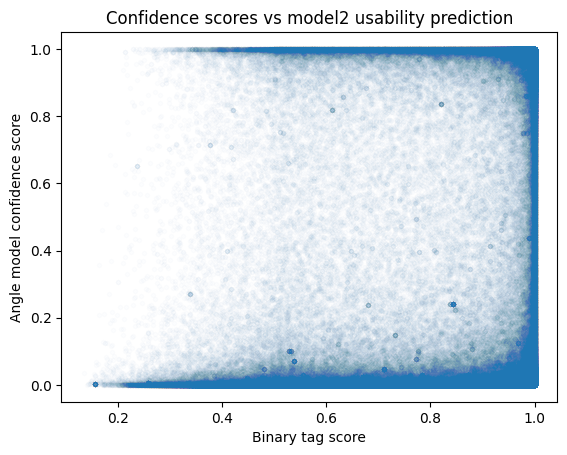

In [29]:
binmodel = 'model2'     ##change to compare different models

spread_query = f"""SELECT a.model_score as anglescore, b.{binmodel}_results as binscore, i.image_path
               FROM angletag_predicts a
               JOIN bintag_predicts b ON a.image_id = b.image_id
               JOIN images i on i.id = a.image_id
               LIMIT 1000000"""
df_spread = pd.DataFrame(db.execute_query(spread_query))

plt.scatter(
    x=df_spread.anglescore,
    y=df_spread.binscore,
    marker='.',
    alpha=0.01
    )
plt.title(f'Confidence scores vs {binmodel} usability prediction')
plt.xlabel('Binary tag score')
plt.ylabel('Angle model confidence score')
;

This plot is strongly suggesting that the angle tagging model picked up a lot of the false positives. This confidence score of the angle model alghorithm could be an interesting feature to use when re-evaluating the binary tagging process. This is however NOT part of the intended goals but for future follow up. These false nevatieves are the instances that you find at the horizontal top towards the left of the plot. Similarly this model might be able to identify unusable images that the binary tagger did not manage to filter out; these false positives would be found in the bottomright section of the plot above. Let's visually verify this assumption: 

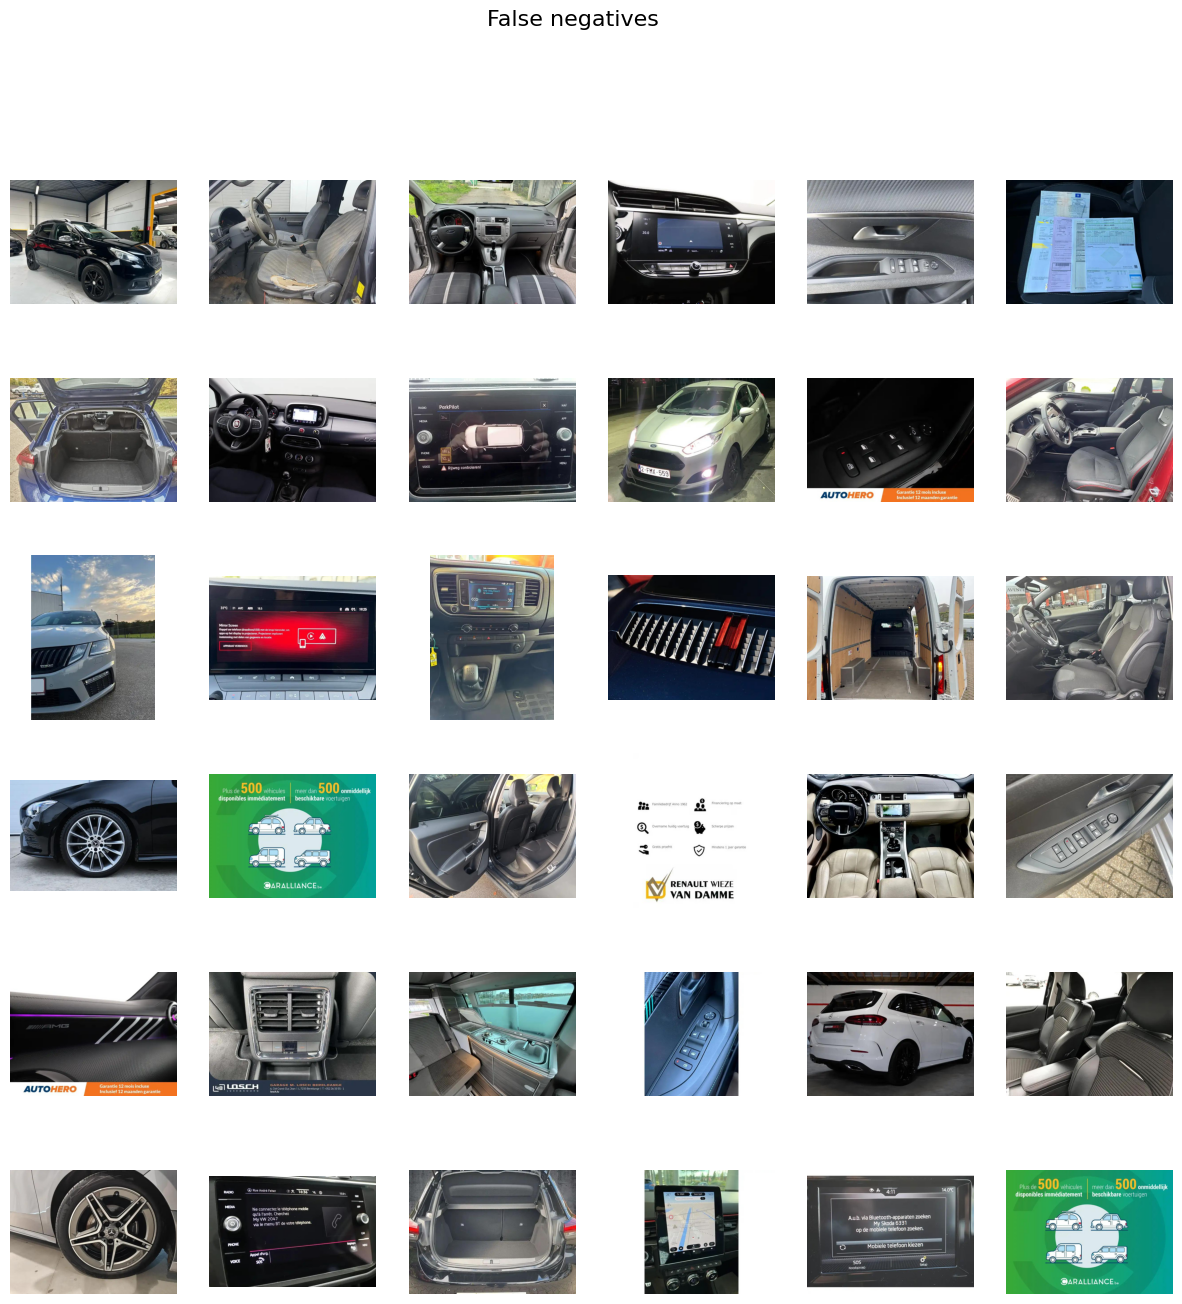

In [ ]:
df_spread2 = file_io.make_absolute_path(df_spread, basedir, 'image_path', 'abs_path')
#find false negatives (according to the binary tagging proces)
implot.plot_images_as_grid(df_spread2.query("binscore <= 0.5 & anglescore >= 0.98")['abs_path'], 'Possible false negatives', 6)


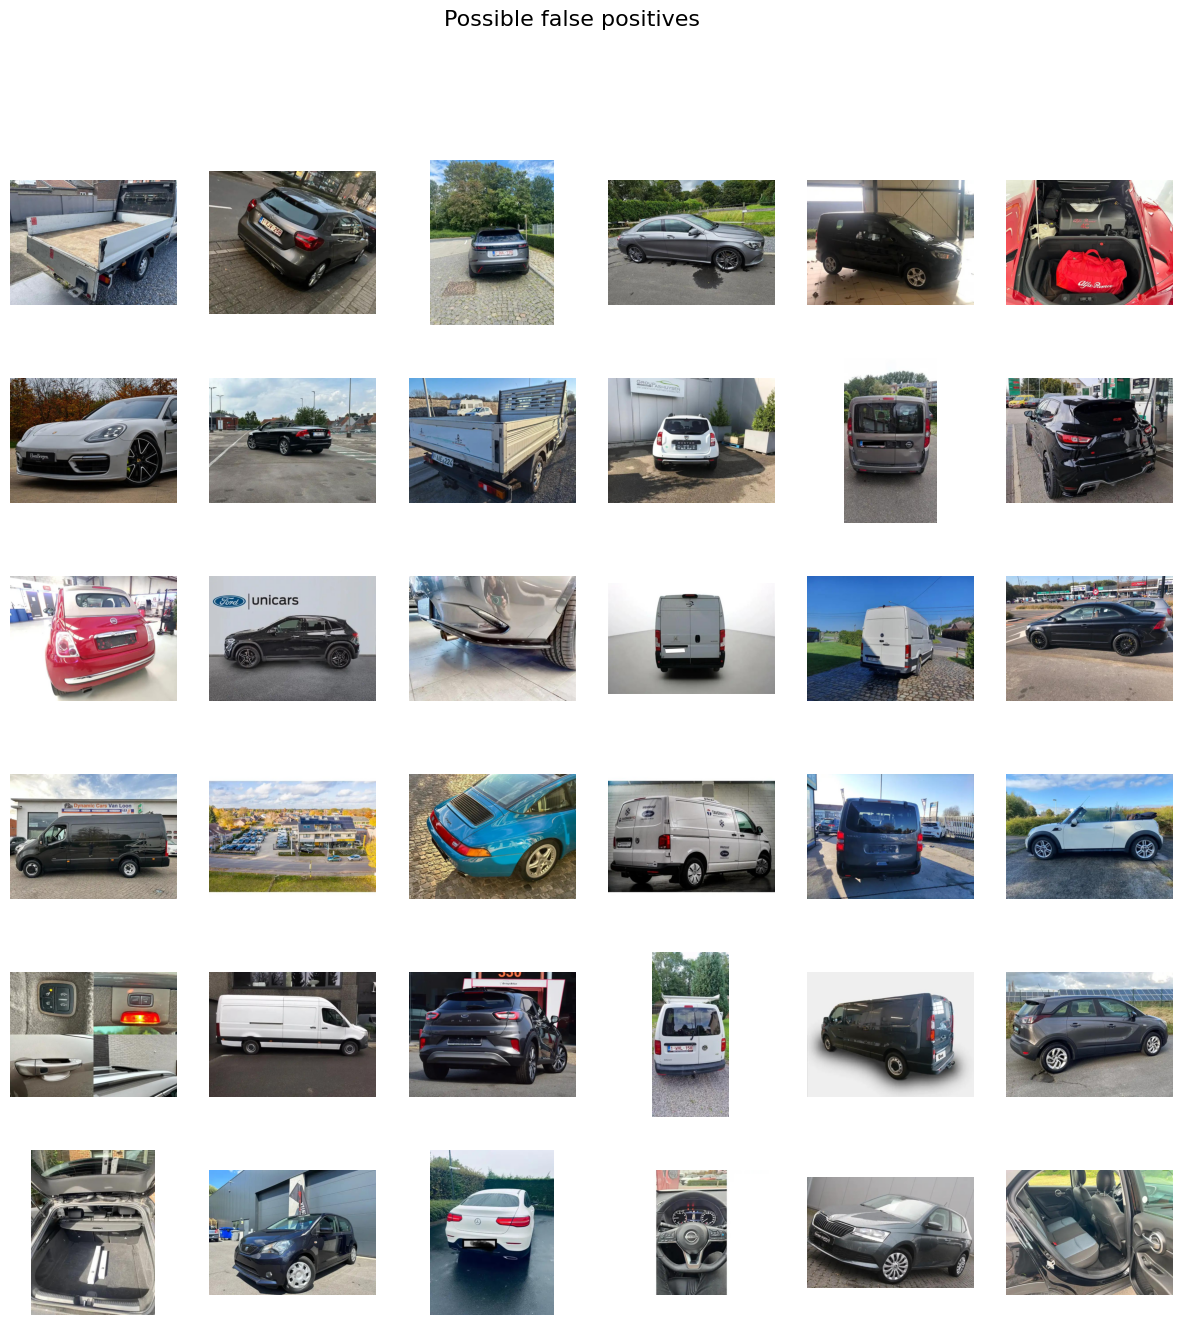

In [43]:
implot.plot_images_as_grid(df_spread2.query("binscore >= 0.98 & anglescore <= 0.5")['abs_path'], 'Possible false positives', 6)


Scratch this thought - both opposites of the graph seem to have a lot of unwanted results in there. 

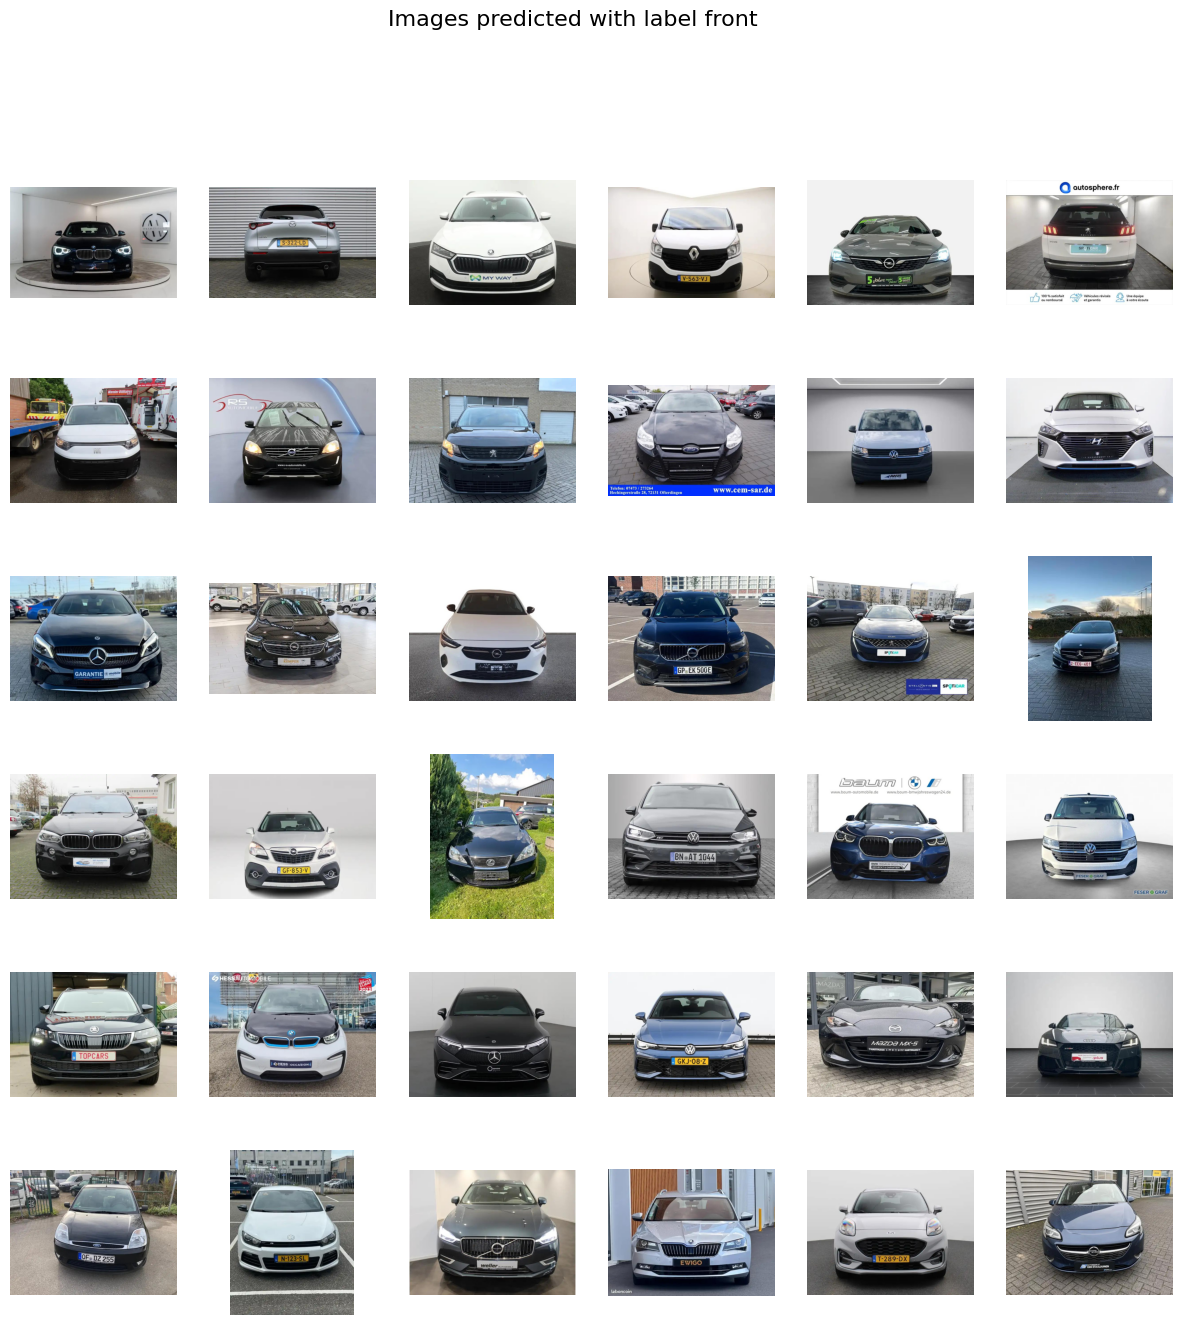

In [58]:
#Let's see the images for a given angle: 
angle = 'front'

implot.plot_images_as_grid(df.query(f"model_label == '{angle}'")['abs_path'], f'Images predicted with label {angle}', 6)


Not bad: here we have the front label and we see one rear image in there, this was something we noticed in the confusion matrices that the model has a high chance of confusing the data with values from the opposite side. I'm frankly surprised it seems to have less trouble with edge cases where a human expert would doubt between front and frontleft/frontright. There are cases like this for sure, if you replot it enough you find them. But here we visually reconfirm the error distribution pattern that the confusion matrices showed: i.e. more trouble with oppositive views than with nearby views - interesting. 